# structflo-cser — Quickstart

This notebook walks through the **Chemical Structure + Label Extraction** pipeline
step-by-step, then shows the one-liner convenience API.

**Pipeline stages:**
1. **Detect** — YOLO finds chemical structures and compound labels
2. **Match** — pair each structure with its label (three strategies available; see below)
3. **Extract** — DECIMER converts structure crops → SMILES; EasyOCR reads label text

All examples use the bundled synthetic page `notebook-data/syn-1.jpg`.


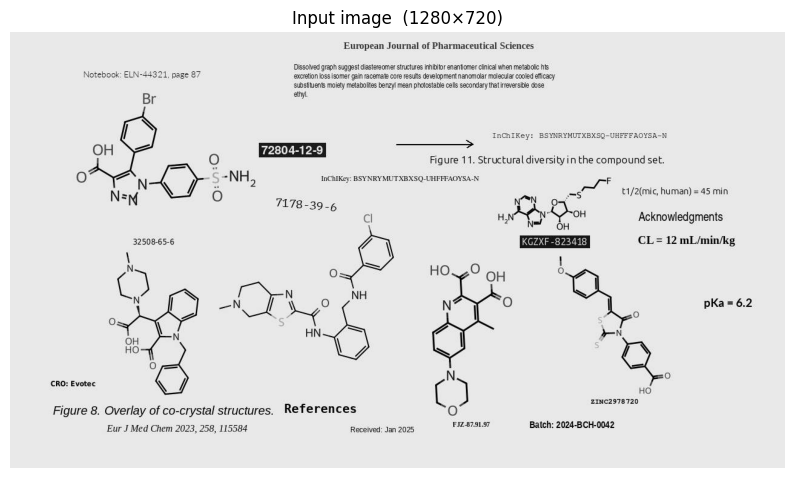

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

from structflo.cser.viz import plot_detections, plot_pairs, plot_crops, plot_results

# Choose a test image (change the filename as needed)
IMAGE_PATH = Path("notebook-data/syn-1.jpg")
assert IMAGE_PATH.exists(), f"Image not found: {IMAGE_PATH}"

img = Image.open(IMAGE_PATH).convert("RGB")
plt.figure(figsize=(10, 14))
plt.imshow(img)
plt.axis("off")
plt.title(f"Input image  ({img.width}×{img.height})")
plt.show()

## Part 1 — Step-by-step pipeline

### 1a. Create the pipeline

The pipeline is lazy — YOLO weights, DECIMER, and EasyOCR are only loaded on first use.

In [2]:
from structflo.cser.pipeline import ChemPipeline

# Default matcher is the RelationalMatcher (geometry-only optimal transport).
# Pass matcher=HungarianMatcher() or LearnedMatcher() to switch strategies (see end).
pipeline = ChemPipeline(conf=0.70)
print('Pipeline created (models load lazily on first use)')


/home/sidx/workspace/struct_labels/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Pipeline created (models load lazily on first use)


/home/sidx/workspace/struct_labels/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


### 1b. Detect — find structures and labels

`pipeline.detect()` runs YOLO and returns a flat list of `Detection` objects (class 0 = structure, class 1 = label).

In [3]:
detections = pipeline.detect(IMAGE_PATH)

n_struct = sum(1 for d in detections if d.class_id == 0)
n_label  = sum(1 for d in detections if d.class_id == 1)
print(f"Found {n_struct} structures and {n_label} labels  ({len(detections)} total detections)")

Found 6 structures and 6 labels  (12 total detections)


In [4]:
detections

[Detection(bbox=BBox(x1=160.52792358398438, y1=363.0567626953125, x2=314.618896484375, y2=599.7767333984375), conf=0.9738272428512573, class_id=0),
 Detection(bbox=BBox(x1=902.6507568359375, y1=369.44659423828125, x2=1092.1990966796875, y2=598.6211547851562), conf=0.9723632335662842, class_id=0),
 Detection(bbox=BBox(x1=107.58018493652344, y1=98.94857788085938, x2=406.5428466796875, y2=288.38006591796875), conf=0.9716644883155823, class_id=0),
 Detection(bbox=BBox(x1=343.604736328125, y1=293.5107421875, x2=635.7225341796875, y2=542.555908203125), conf=0.9706407189369202, class_id=0),
 Detection(bbox=BBox(x1=692.1962890625, y1=380.76324462890625, x2=832.071533203125, y2=634.1963500976562), conf=0.9640052914619446, class_id=0),
 Detection(bbox=BBox(x1=804.2669067382812, y1=238.38906860351562, x2=993.8179321289062, y2=328.2325134277344), conf=0.9621526598930359, class_id=0),
 Detection(bbox=BBox(x1=406.4976806640625, y1=178.89930725097656, x2=525.7045288085938, y2=210.8629608154297), conf

### Visualise detections

Green = chemical structure, Blue = compound label.

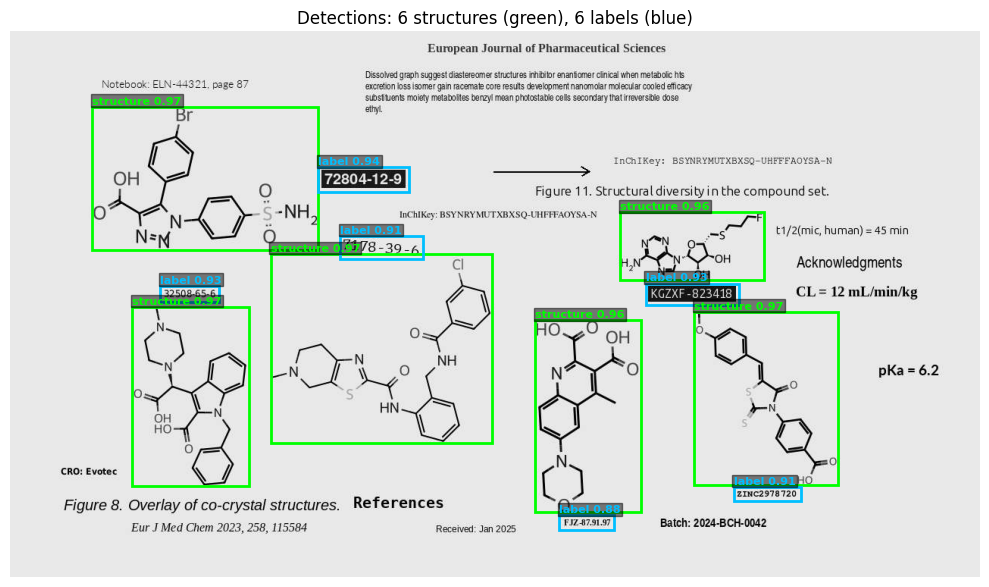

In [5]:
fig = plot_detections(img, detections)
plt.show()

### 1c. Match — pair structures with labels

`pipeline.match()` pairs each structure with its label using the configured matcher
(the relational optimal-transport matcher by default).


In [6]:
pairs = pipeline.match(detections)
print(f"Matched {len(pairs)} structure–label pairs\n")

for i, p in enumerate(pairs):
    sc = p.structure.bbox.centroid
    lc = p.label.bbox.centroid
    conf = f"conf={p.match_confidence:.2f}" if p.match_confidence is not None else f"dist={p.match_distance:.0f}px"
    print(f"  Pair {i}: {conf}  "
          f"structure@({sc[0]:.0f},{sc[1]:.0f})  label@({lc[0]:.0f},{lc[1]:.0f})")


Matched 6 structure–label pairs

  Pair 0: conf=0.98  structure@(238,481)  label@(237,346)
  Pair 1: conf=0.99  structure@(997,484)  label@(999,610)
  Pair 2: conf=0.99  structure@(257,194)  label@(466,195)
  Pair 3: conf=0.98  structure@(490,418)  label@(490,285)
  Pair 4: conf=0.99  structure@(762,507)  label@(761,648)
  Pair 5: conf=0.99  structure@(899,283)  label@(900,346)


In [7]:
pairs

[CompoundPair(structure=Detection(bbox=BBox(x1=160.52792358398438, y1=363.0567626953125, x2=314.618896484375, y2=599.7767333984375), conf=0.9738272428512573, class_id=0), label=Detection(bbox=BBox(x1=197.7435302734375, y1=335.1981201171875, x2=275.79022216796875, y2=356.29736328125), conf=0.9254157543182373, class_id=1), match_distance=0.017646610736846924, smiles=None, label_text=None, match_confidence=0.9823533892631531),
 CompoundPair(structure=Detection(bbox=BBox(x1=902.6507568359375, y1=369.44659423828125, x2=1092.1990966796875, y2=598.6211547851562), conf=0.9723632335662842, class_id=0), label=Detection(bbox=BBox(x1=954.5401611328125, y1=600.9393310546875, x2=1042.744384765625, y2=618.9158935546875), conf=0.9125977754592896, class_id=1), match_distance=0.011122167110443115, smiles=None, label_text=None, match_confidence=0.9888778328895569),
 CompoundPair(structure=Detection(bbox=BBox(x1=107.58018493652344, y1=98.94857788085938, x2=406.5428466796875, y2=288.38006591796875), conf=0

### Visualise matched pairs

Orange lines connect each structure to its matched label.

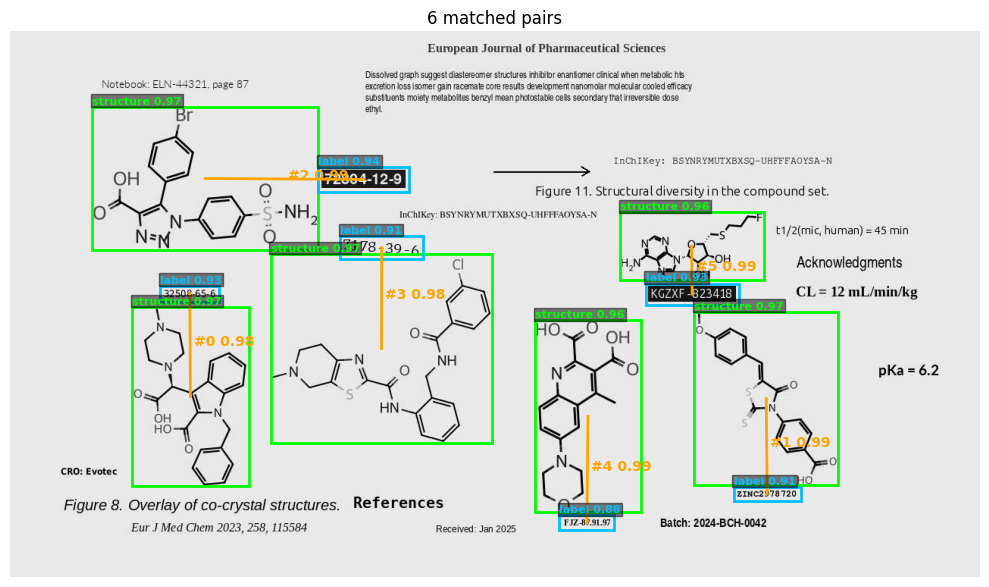

In [8]:
fig = plot_pairs(img, pairs)
plt.show()

### 1d. Show cropped regions for each pair

For each matched pair, we crop the structure and label regions from the original image.

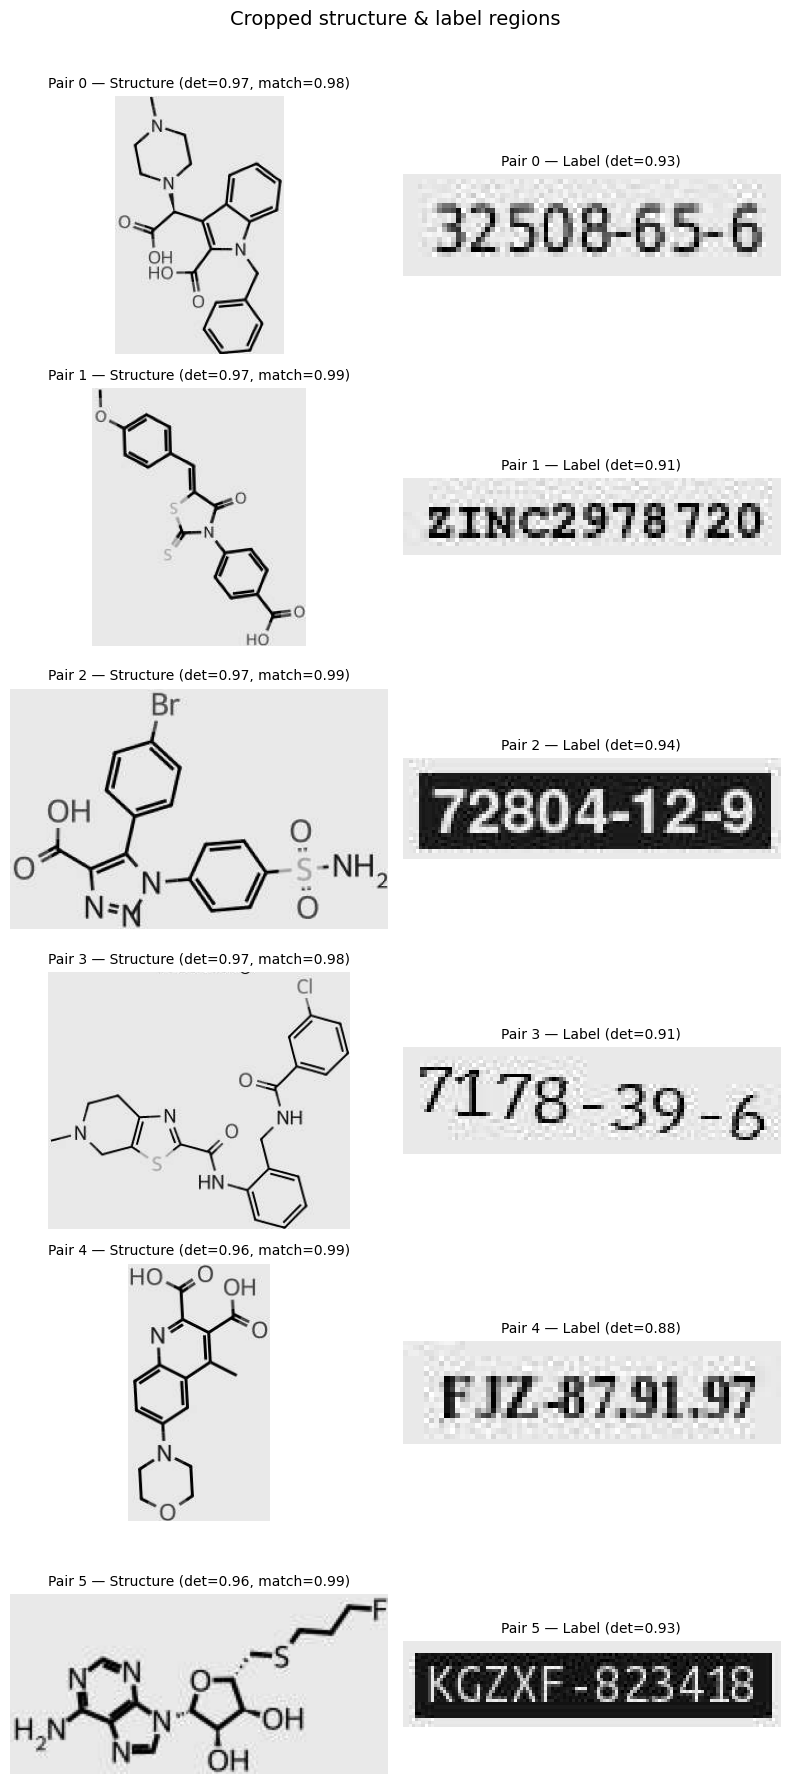

In [9]:
fig = plot_crops(img, pairs)
plt.show()

### 1e. Extract — SMILES and label text

`pipeline.enrich()` runs DECIMER on each structure crop and EasyOCR on each label crop, populating `pair.smiles` and `pair.label_text`.

In [10]:
enriched_pairs = pipeline.enrich(pairs, IMAGE_PATH)

for i, p in enumerate(enriched_pairs):
    print(f"Pair {i}:")
    print(f"  SMILES:     {p.smiles}")
    print(f"  Label text: {p.label_text}")
    print(f"  Distance:   {p.match_distance:.0f}px")
    print()

I0000 00:00:1780110837.071027  262168 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 44735 MB memory:  -> device: 0, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:41:00.0, compute capability: 8.9


Pair 0:
  SMILES:     CN1CCN(CC1)[C@@H](C2=C(C(=O)O)N(CC3=CC=CC=C3)C4=CC=CC=C42)C(=O)O
  Label text: 32508-65-6
  Distance:   0px

Pair 1:
  SMILES:     COC1=CC=C(C=C1)C=C2C(=O)N(C3=CC=C(C=C3)C(=O)O)C(=S)S2
  Label text: ZINC2978 720
  Distance:   0px

Pair 2:
  SMILES:     C1=CC(=CC=C1C2=C(C(=O)O)N=NN2C3=CC=C(C=C3)S(=O)(=O)N)Br
  Label text: 72804-12-9
  Distance:   0px

Pair 3:
  SMILES:     CN1CCC2=C(C1)SC(=N2)C(=O)NC3=C(C=CC=C3)CNC(=O)C4=CC=CC(=C4)Cl.[V]
  Label text: 7178-39-6
  Distance:   0px

Pair 4:
  SMILES:     CC1=C(C(=NC2=CC=C(C=C12)N3CCOCC3)C(=O)O)C(=O)O
  Label text: FJZ 87.91.97
  Distance:   0px

Pair 5:
  SMILES:     C(CF)CSC[C@@H]1[C@H]([C@H]([C@H](N2C=NC3=C2N=CN=C3N)O1)O)O
  Label text: KGZXF -823418
  Distance:   0px



### 1f. Results as a DataFrame

In [11]:
df = ChemPipeline.to_dataframe(enriched_pairs)
df

,structure_bbox,structure_conf,label_bbox,label_conf,match_distance,match_confidence,smiles,label_text
0,"[160.52792358398438, 363.0567626953125, 314.61...",0.9738,"[197.7435302734375, 335.1981201171875, 275.790...",0.9254,0.02,0.9824,CN1CCN(CC1)[C@@H](C2=C(C(=O)O)N(CC3=CC=CC=C3)C...,32508-65-6
1,"[902.6507568359375, 369.44659423828125, 1092.1...",0.9724,"[954.5401611328125, 600.9393310546875, 1042.74...",0.9126,0.01,0.9889,COC1=CC=C(C=C1)C=C2C(=O)N(C3=CC=C(C=C3)C(=O)O)...,ZINC2978 720
2,"[107.58018493652344, 98.94857788085938, 406.54...",0.9717,"[406.4976806640625, 178.89930725097656, 525.70...",0.9374,0.01,0.9862,C1=CC(=CC=C1C2=C(C(=O)O)N=NN2C3=CC=C(C=C3)S(=O...,72804-12-9
3,"[343.604736328125, 293.5107421875, 635.7225341...",0.9706,"[435.07257080078125, 269.6304626464844, 544.78...",0.9051,0.02,0.9762,CN1CCC2=C(C1)SC(=N2)C(=O)NC3=C(C=CC=C3)CNC(=O)...,7178-39-6
4,"[692.1962890625, 380.76324462890625, 832.07153...",0.9640,"[724.5511474609375, 637.992431640625, 797.0832...",0.8805,0.01,0.9895,CC1=C(C(=NC2=CC=C(C=C12)N3CCOCC3)C(=O)O)C(=O)O,FJZ 87.91.97
5,"[804.2669067382812, 238.38906860351562, 993.81...",0.9622,"[838.287841796875, 332.28887939453125, 961.052...",0.9333,0.01,0.9885,C(CF)CSC[C@@H]1[C@H]([C@H]([C@H](N2C=NC3=C2N=C...,KGZXF -823418


---

## Part 2 — Full pipeline in one call

Everything above (detect → match → enrich) can be done in a single `process()` call.

In [12]:
from structflo.cser.pipeline import ChemPipeline

# Default matcher is the RelationalMatcher (geometry-only optimal transport).
# Pass matcher=HungarianMatcher() or LearnedMatcher() to switch strategies (see end).
pipeline = ChemPipeline(conf=0.70)
print('Pipeline created (models load lazily on first use)')


Pipeline created (models load lazily on first use)


/home/sidx/workspace/struct_labels/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [13]:
# One-liner: detect + match + extract SMILES & OCR in a single call
results = pipeline.process(IMAGE_PATH)

# View as DataFrame
ChemPipeline.to_dataframe(results)

,structure_bbox,structure_conf,label_bbox,label_conf,match_distance,match_confidence,smiles,label_text
0,"[160.52792358398438, 363.0567626953125, 314.61...",0.9738,"[197.7435302734375, 335.1981201171875, 275.790...",0.9254,0.02,0.9779,CN1CCN(CC1)[C@@H](C2=C(C(=O)O)N(CC3=CC=CC=C3)C...,32508-65-6
1,"[902.6507568359375, 369.44659423828125, 1092.1...",0.9724,"[954.5401611328125, 600.9393310546875, 1042.74...",0.9126,0.01,0.9904,COC1=CC=C(C=C1)C=C2C(=O)N(C3=CC=C(C=C3)C(=O)O)...,ZINC2978 720
2,"[107.58018493652344, 98.94857788085938, 406.54...",0.9717,"[406.4976806640625, 178.89930725097656, 525.70...",0.9374,0.01,0.9886,C1=CC(=CC=C1C2=C(C(=O)O)N=NN2C3=CC=C(C=C3)S(=O...,72804-12-9
3,"[343.604736328125, 293.5107421875, 635.7225341...",0.9706,"[435.07257080078125, 269.6304626464844, 544.78...",0.9051,0.03,0.9724,CN1CCC2=C(C1)SC(=N2)C(=O)NC3=C(C=CC=C3)CNC(=O)...,7178-39-6
4,"[692.1962890625, 380.76324462890625, 832.07153...",0.9640,"[724.5511474609375, 637.992431640625, 797.0832...",0.8805,0.01,0.9904,CC1=C(C(=NC2=CC=C(C=C12)N3CCOCC3)C(=O)O)C(=O)O,FJZ 87.91.97
5,"[804.2669067382812, 238.38906860351562, 993.81...",0.9622,"[838.287841796875, 332.28887939453125, 961.052...",0.9333,0.01,0.9905,C(CF)CSC[C@@H]1[C@H]([C@H]([C@H](N2C=NC3=C2N=C...,KGZXF -823418


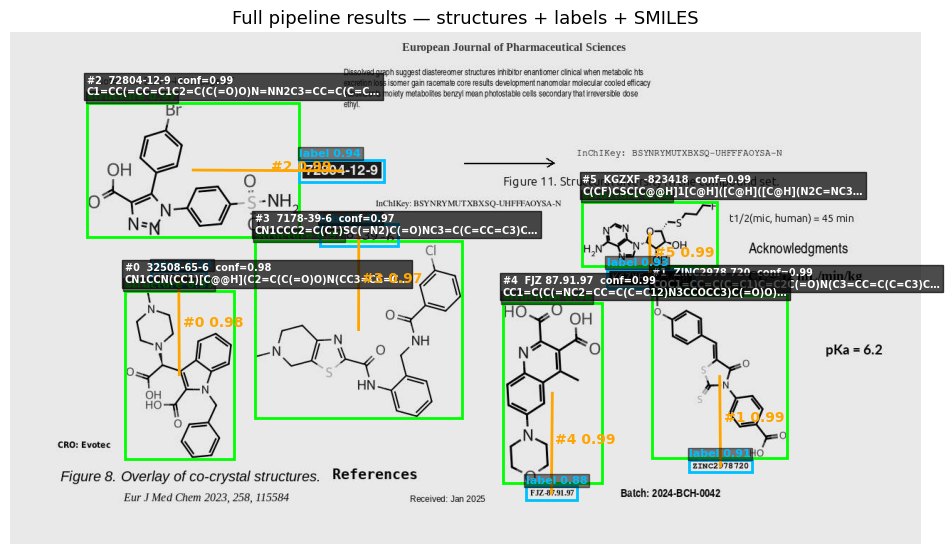

In [14]:
fig = plot_results(img, results)
plt.show()

### Export to JSON

In [15]:
print(ChemPipeline.to_json(results))

[
  {
    "structure_bbox": [
      160.52792358398438,
      363.0567626953125,
      314.618896484375,
      599.7767333984375
    ],
    "structure_conf": 0.9738,
    "label_bbox": [
      197.7435302734375,
      335.1981201171875,
      275.79022216796875,
      356.29736328125
    ],
    "label_conf": 0.9254,
    "match_distance": 0.02,
    "match_confidence": 0.9779,
    "smiles": "CN1CCN(CC1)[C@@H](C2=C(C(=O)O)N(CC3=CC=CC=C3)C4=CC=CC=C42)C(=O)O",
    "label_text": "32508-65-6"
  },
  {
    "structure_bbox": [
      902.6507568359375,
      369.44659423828125,
      1092.1990966796875,
      598.6211547851562
    ],
    "structure_conf": 0.9724,
    "label_bbox": [
      954.5401611328125,
      600.9393310546875,
      1042.744384765625,
      618.9158935546875
    ],
    "label_conf": 0.9126,
    "match_distance": 0.01,
    "match_confidence": 0.9904,
    "smiles": "COC1=CC=C(C=C1)C=C2C(=O)N(C3=CC=C(C=C3)C(=O)O)C(=S)S2",
    "label_text": "ZINC2978 720"
  },
  {
    "structure

### Final annotated image with extracted info

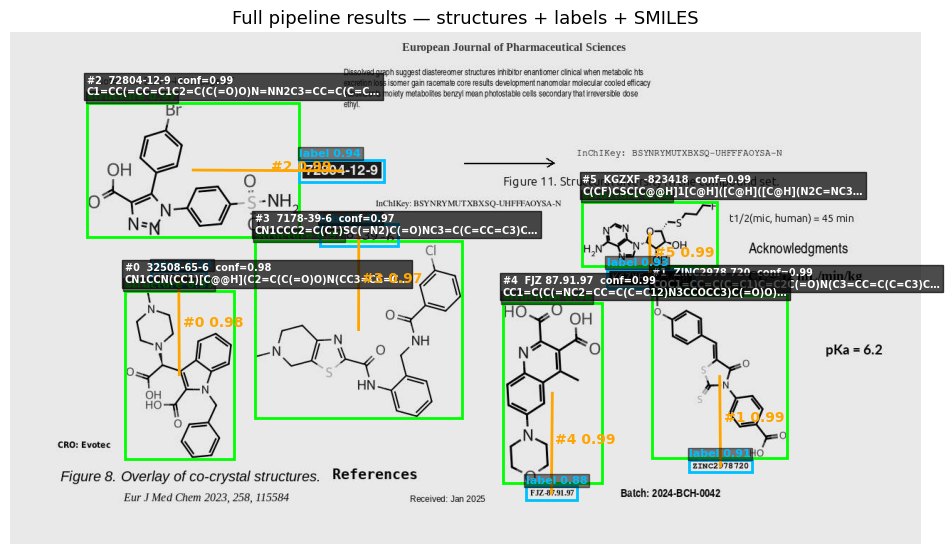

In [16]:
fig = plot_results(img, results)
plt.show()

---

## Part 3 — Choosing a matcher

The matcher pairs each detected structure with its label. Three strategies share a common
interface; pass one to `ChemPipeline(matcher=...)`:

| Matcher | What it does | Weights |
|---|---|---|
| `RelationalMatcher` | **Default.** Geometry-only transformer over all page detections + Sinkhorn optimal transport with learnable “dustbins” for unmatched structures. | `cser-relmatcher` |
| `HungarianMatcher` | Parameter-free centroid-distance assignment; a strong baseline on clean detections. | none |
| `LearnedMatcher` | Visual CNN scorer (LPS) over structure/label crops + geometry. | `cser-lps` |


In [17]:
from structflo.cser.pipeline.matcher import HungarianMatcher
from structflo.cser.relmatch import RelationalMatcher
from structflo.cser.lps import LearnedMatcher

# Detect once, then re-match with each strategy (matching is cheap).
dets = pipeline.detect(IMAGE_PATH)
img_arr = plt.imread(str(IMAGE_PATH))

for name, m in {
    "Relational (default)": RelationalMatcher(),
    "Hungarian (distance)": HungarianMatcher(),
    "LPS (visual)": LearnedMatcher(),
}.items():
    paired = m.match(dets, image=img_arr)
    print(f"{name:22s} -> {len(paired)} pairs")


/home/sidx/workspace/struct_labels/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Relational (default)   -> 6 pairs
Hungarian (distance)   -> 6 pairs
LPS (visual)           -> 6 pairs
